# Aprendizaje Automático
# Proyecto final

Profesor: Juan Luis Crespo Mariño

Instituto Tecnológico de Costa Rica,

Programa Ciencia de Datos

---



Medio de entrega: Por medio del TEC-Digital.

Entregables: Un archivo jupyter ( .IPYNB ).

BD utilizada: https://archive.ics.uci.edu/dataset/2/adult


Estudiante:
1. **Jose Pablo Ruiz Myrie**
2. **Nikole Villalobos Lopez**


### Interpretación y análisis de variables seleccionadas
Como se verá al final de este notebook, la variables seleccionadas para llevar a cabo el estudio corresponden a age, workclass, education-num, marital-status, occupation, relationship, race, sex, capital-gain-log, capital-loss-log, hours-per-week y native country 


age (edad): En general las personas de mayor edad pueden haber acumulado más experiencia lo que se podría asociar con mayores ingresos. No obstante, la relación no debe ser necesariamente lineal en todo el rango de edad como reflejan estudios sobre el pico salarial al rededor de 55-64 años.
workclass (Clase de trabajo): El tipo de empleo puede estar relacionado con diferencias salariales. Trabajadores del sector privado, gobierno o trabajadores por cuenta propia pueden presentar patrones distintos de ingreso.
education-enum (Nivel educativo): Un mayor nivel educativo suele asociarse con mayor capital humano y acceso a puestos mejor remunerados
marital-status (Estado civil): Puede captar diferencias en etapa del ciclo de vida, edad y situación socioeconómica. Algunas categorías pueden estar indirectamente relacionadas con ingresos mayores.
occupation (Ocupación): Diferentes ocupaciones presentan distintos niveles de remuneración. Una de las variables que podría tener mayor capacidad explicativa.
relationship (Relación familiar): Puede reflejar indirectamente características del hogar y del ciclo de vida.
race (etnia): Puede reflejar desigualdades socioeconómicas históricas presentes en los datos.
sex (Sexo): Puede captar diferencias de ingreso existentes entre hombres y mujeres dentro del mercado laboral representado en el dataset.
capital-gain-log (Ganancias de capital): Un mayor valor puede estar asociado con individuos que obtienen ingresos adicionales por inversiones o activos, por lo que se esperaría una relación positiva con ingresos superiores a $50K.
capital-loss-log (Pérdidas de capital): Puede reflejar participación en actividades financieras o posesión de activos. Su relación con el nivel de ingreso puede ser menos directa, pero puede ayudar a distinguir diferentes perfiles económicos.
hours-per-week (Horas trabajadas por semana): En principio, trabajar más horas podría aumentar la probabilidad de superar los $50K, aunque un mayor número de horas no garantiza ingresos altos, ya que también depende de la ocupación, nivel educativo y remuneración por hora.
native-country (País de origen): Puede captar diferencias económicas, educativas, migratorias o laborales entre grupos de origen.


En síntesis, se espera que education-num, age, hours-per-week y capital-gain-log presenten una relación positiva con la probabilidad de obtener ingresos superiores a $50K. Asimismo, variables categóricas como occupation y workclass podrían mostrar diferencias importantes entre grupos debido a la heterogeneidad salarial existente entre ocupaciones y tipos de empleo

# Notebook 01 — EDA inicial, valores faltantes y outliers

Este notebook contiene la exploración inicial del dataset Adult, el análisis
de su estructura, el tratamiento de valores faltantes y el estudio de valores
atípicos mediante análisis descriptivo, histogramas, boxplots e IQR.


In [21]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
%pip install matplotlib seaborn scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# ============================================================
# 0. Cargamos las librerias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split



In [24]:
# ============================================================
# PARTE 1. Introducción al dataset, carga, estructura
# ============================================================

# Este dataset contiene información demográfica, eduactiva y laboral sobre
# individuos recopilados a partir del censo de Estados Unidos de 1994.
#
# Los datos incluyen características como edad, nivel educativo, ocupación,
# estado civil, tipo de empleo, cantidad de horas trabajadas por semana,
# ganancias de capital y país de origen. Contamos con datos faltantes para
# native-country  workclass y occupation
#
# El objetivo principal del conjunto de datos es analizar los factores asociados
# al nivel de ingresos de las personas y clasificar si un individuo posee un
# ingreso anual superior o inferior a 50 000 dólares

#Descargamos el repo
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# Unimos las variables predictoras con la variable objetivo
df = pd.concat([X, y], axis=1)

# Visualizamos las primeras filas
df.head()

print("=" * 60)
print("Dimensiones del dataset (filas, columnas):")
print(df.shape)

print("\n" + "=" * 60)
print("Primeras 10 filas:")
print(df.head(10))

print("\n" + "=" * 60)
print("Tipos de datos por columna:")
print(df.dtypes)

print("\n" + "=" * 60)
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\n" + "=" * 60)
print("Estadísticos descriptivos de las variables numéricas:")
print(df.describe())

print("\n" + "=" * 60)
print("Cantidad de filas duplicadas:")
print(df.duplicated().sum())

print("=" * 60)




Dimensiones del dataset (filas, columnas):
(48842, 15)

Primeras 10 filas:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   
5   37           Private  284582    Masters             14   
6   49           Private  160187        9th              5   
7   52  Self-emp-not-inc  209642    HS-grad              9   
8   31           Private   45781    Masters             14   
9   42           Private  159449  Bachelors             13   

          marital-status         occupation   relationship   race     sex  \
0          Never-married       Adm-clerical  Not-in-family  White    Male   
1     Married-civ-spouse    Exec-managerial        Husband  White    Male   
2          

In [25]:
# ============================================================
# PARTE 2. Identificacion y tratamiento de valores faltantes
# ============================================================

#-------------------------------------------------------------
# 2.1 Identificacion y análisis de valores faltantes
#-------------------------------------------------------------

# Definimos las variables con valores faltamtes
faltantes = ['workclass', 'occupation', 'native-country']

# Definimos las variables númercas que se utilizan para comparar observaciones
# con y sin datos faltantes
numericas = ['age', 'education-num', 'hours-per-week', 'capital-gain', 
             'capital-loss']

# Realizamos el analisis de valores faltantes con respecto a variables numéricas
for col in faltantes:
    
    print(f"\n ======== Análisis de {col} =======")
    
    # Realizamos un indicador donde False la observación tiene dato y True = NA
    indicador = df[col].isnull()
    
    # Realizamos la comparación de medias donde comparamos el promedio de las 
    # variables numéricas. Si existen diferencias importantes entre ambos grupos
    # se podría sugreir que la ausencia de datos no es completamente aleatoria.

    print("\nPromedios:")
    
    print(df.groupby(indicador)[numericas].mean().round(2))
    
    # Comparación con income. Calculamos  el porcentaje de valores presentes y 
    # faltantes en income.
    print("\nPorcentaje según income:")
    
    print(pd.crosstab(df['income'], indicador, normalize='index').round(3) * 
          100)
    
    faltantes = ['workclass', 'occupation', 'native-country']

# Definimos las variables cátegoricas que se utilizan para comparar observaciones
# con y sin datos faltantes

categoricas = ['sex', 'marital-status', 'race', 'income']

# Realizamos el analisis de valores faltantes con respecto a variables cátegoricas
for col in faltantes:
    
    print(f"\n======== Análisis de {col} ========")
    
    # Realizamos un indicador donde False la observación tiene dato y True = NA
    indicador = df[col].isnull()
    
    # Recorremos cada una de las variables categóricas
    for var in categoricas:
        
        # Creamos una tabla cruzada que muestra qué porcentaje de cada categoría 
        # tiene o no tiene un valor faltante.
        print(f"\nPorcentaje según {var}:")
        
        print(pd.crosstab(df[var], indicador, normalize='index').round(2) * 100)


 ======== Análisis de workclass =======

Promedios:
             age  education-num  hours-per-week  capital-gain  capital-loss
workclass                                                                  
False      38.64          10.10           40.60       1094.64         87.64
True       38.58           9.23           31.61        304.95         80.74

Porcentaje según income:
workclass  False  True 
income                 
<=50K      100.0    0.0
<=50K.      92.9    7.1
>50K       100.0    0.0
>50K.       98.1    1.9

 ======== Análisis de occupation =======

Promedios:
              age  education-num  hours-per-week  capital-gain  capital-loss
occupation                                                                  
False       38.65          10.10            40.6       1094.71         87.64
True        38.52           9.23            31.6        304.01         80.49

Porcentaje según income:
occupation  False  True 
income                  
<=50K       100.0    0.0
<=50K.    

### *Análisis de resultado:*

Para el caso de workclass y occupation, el patrón de ausencia de datos no parece ser completamente aleatorio. Las observaciones con datos faltantes vs no faltantes cuentan con diferencias como:

- hours-per-week: aproximadamente 40.6 cuando hay dato vs 31.6 cuando falta
- education-num: aproximadamente 10.1 vs 9.23.
- income <=50K: alrededor de 2.4% de faltantes.
- income >50K: solo alrededor de 0.6% de faltantes.
- En marital-status, algunas categorías tienen porcentajes claramente distintos, por ejemplo Married-AF-spouse con aproximadamente 8.1% de faltantes.

Así, esto sugeriría que la ausencia de workclass y occupation está relacionada con otras características observadas. Descriptivamente, es razonable decir que son compatibles con MAR.

Para native-country, el patrón es mucho menos claro. En varias variables los grupos son muy similares:

- age: 38.64 vs 38.87.
- hours-per-week: 40.42 vs 40.01.
- income: 0.54% vs 0.63% de faltantes.
- sex: 0.52% vs 0.58%.


In [26]:
#-------------------------------------------------------------
# 2.2 Convertimos el identificador de los valores faltantes a NaN
#-------------------------------------------------------------


columnas_faltantes = ["workclass", "occupation", "native-country"]

df[columnas_faltantes] = df[columnas_faltantes].replace("?", np.nan)

# Corregimos las etiquetas de income
df["income"] = (
    df["income"]
    .str.strip()
    .str.rstrip(".")
)

#-------------------------------------------------------------
# 2.3 Separamos variables predictoras y variable objetivo
#-------------------------------------------------------------
X = df.drop(columns="income")
y = df["income"]

# Separamos entrenamiento y prueba antes de imputar para evitar data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#-------------------------------------------------------------
# 2.3 Comenzamos el proceso de Imputación Predictiva e Imputación Simple
#-------------------------------------------------------------
# Tal como lo indicamos anteriormente,  para workclass y occupation la presencia 
# de los valores nulos parece estar relacionada con  otras variables observadas, 
# por lo que el patrón es compatible con MAR. Por esta razón, para workclass y 
# occupation utilizaremos una imputación predictiva.
# Por otro lado, native-country presenta un patrón de ausencia mucho menos
# marcado, por lo que utilizaremos una imputación simple mediante la categoría 
# más frecuente (moda).

#Definimos las variables predictoras para realizar el random forest
variables_predictoras = ["age", "education-num", "hours-per-week", 
                         "capital-gain", "capital-loss", "sex", "marital-status", 
                         "race",]


# Definimos la función de imputación
def imputar_mar(X_train, X_test, variable_objetivo, predictoras):
    
    # Separamos los registros que tienen el dato disponible de aquellos que 
    # tienen el dato faltante
    completos = X_train[X_train[variable_objetivo].notna()].copy()
    
    faltantes_train = X_train[X_train[variable_objetivo].isna()].copy()
    faltantes_test = X_test[X_test[variable_objetivo].isna()].copy()
    
    
    # Definimos X e y donde X_train contiene las variables que utilizaremos para 
    # predecir la categoría faltante y y_train contiene la variable que queremos
    # imputar
    X_modelo = completos[predictoras]
    y_modelo = completos[variable_objetivo]
    
    # Registros donde debemos hacer la predicción
    X_faltantes_train = faltantes_train[predictoras]
    X_faltantes_test = faltantes_test[predictoras]
    
    
    # Identificamos y clasificamos las variables por cátegoricas y númericas
    numericas = X_modelo.select_dtypes(include=["number"]).columns.tolist()
    categoricas = X_modelo.select_dtypes(include=["object", "category"]).columns.tolist()
    
    
    # Realizamos el preprocesamiento donde para las variables numéricas usamos 
    # mediana en caso de que exista algún faltante y para las categóricas usamos
    # la moda y posteriormente One Hot Encoding.
    
    preprocesador = ColumnTransformer(
        transformers=[
        
            (
                "num", SimpleImputer(strategy="median"), numericas),
            
            (
                "cat", Pipeline( steps=[
                        
                        (
                            "imputer",
                            SimpleImputer(strategy="most_frequent")
                        ),
                        
                        (
                            "encoder",
                            OneHotEncoder(handle_unknown="ignore")
                        )
                    ]
                ),
                categoricas
            )
        ]
    )
    
    
    # En el modelo de clasificación Utilizamos Random Forest para estimar la 
    # categoría más probable de cada observación faltante.
    
    modelo = Pipeline(
        steps=[
            
            (
                "preprocesamiento", preprocesador
            ),
            
            (
                "modelo", 
                RandomForestClassifier(n_estimators=100, random_state=42)
            )
        ]
    )
    
    
    # Realizamos el entrenamiento del modelo 
    modelo.fit(X_modelo, y_modelo)
    
    
    # Realizamos la predicción de valores faltantes
    if len(X_faltantes_train) > 0:
        predicciones_train = modelo.predict(X_faltantes_train)
        
        # Ahora realizamos la sustitución de los valores nulos por los predichos
        X_train.loc[
            X_train[variable_objetivo].isna(),
            variable_objetivo
        ] = predicciones_train
    
    
    if len(X_faltantes_test) > 0:
        predicciones_test = modelo.predict(X_faltantes_test)
        
        # Ahora realizamos la sustitución de los valores nulos por los predichos
        X_test.loc[
            X_test[variable_objetivo].isna(),
            variable_objetivo
        ] = predicciones_test
  
    return X_train, X_test


# Realizamos la imputación MAR de workclass
X_train, X_test = imputar_mar(
    X_train, X_test, "workclass", variables_predictoras
)


# Realizamos la imputación MAR de occupations
X_train, X_test = imputar_mar(
    X_train, X_test, "occupation", variables_predictoras
)


# Realizamos la imputación simple de native-country. Debido a que native-country 
# presentó diferencias mucho menores entre los registros completos y los 
# incompletos, utilizamos la moda como estrategia de imputación simple.

imputer_native_country = SimpleImputer(strategy="most_frequent")

X_train[["native-country"]] = (
    imputer_native_country.fit_transform(
        X_train[["native-country"]]
    )
)

X_test[["native-country"]] = (
    imputer_native_country.transform(
        X_test[["native-country"]]
    )
)

#-------------------------------------------------------------
# 2.4 Verificación final de que los valores fueron sustituidos 
# correctamente
#-------------------------------------------------------------

print("\n" + "=" * 60)
print("Valores faltantes post imputación")
print("=" * 60)

print("X_train:")
print(
    X_train[
        ["workclass", "occupation", "native-country"]
    ].isnull().sum()
)

print("\nX_test:")
print(
    X_test[
        ["workclass", "occupation", "native-country"]
    ].isnull().sum()
)

print("=" * 60)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\3411745009.py:73: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = X_modelo.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\3411745009.py:73: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https


Valores faltantes post imputación
X_train:
workclass         0
occupation        0
native-country    0
dtype: int64

X_test:
workclass         0
occupation        0
native-country    0
dtype: int64


In [27]:
# ============================================================
# PARTE 3. Tratamiento de outliers
# ============================================================

# Realizamos un análisis descriptivo de las variables con el fin de conocer
# sus principales características. Al comparar la mediana con la media de
# variables como age, education-num y hours-per-week, observamos que sus valores
# son relativamente cercanos. Esto sugiere que estas variables no presentan
# una asimetría extremadamente marcada. Sin embargo, esta comparación por sí
# sola no permite determinar la presencia o ausencia de valores atípicos.
# Además, podemos observar que, para estas variables, los valores mínimos y
# máximos pueden considerarse plausibles de acuerdo con el significado de cada
# variable. Por ejemplo, en age encontramos edades entre 17 y 90 años, valores
# que son posibles dentro de la población analizada. Por lo tanto, aunque algunos
# de estos valores puedan ser identificados posteriormente como atípicos mediante
# métodos estadísticos, esto no significa necesariamente que sean errores.
# Por otro lado, la desviación estándar de estas variables nos permite evaluar
# qué tan dispersos se encuentran los datos respecto a su media. No obstante,
# una desviación estándar elevada o reducida no permite, por sí sola, confirmar
# la presencia o ausencia de outliers, por lo que será necesario complementar
# este análisis con métodos como IQR y herramientas gráficas como el boxplot.
# En contraste, capital-gain y capital-loss presentan una distribución mucho
# más particular. En estas variables existe una fuerte concentración de valores
# en 0 y algunos valores positivos considerablemente más altos. Esto provoca una
# diferencia importante entre la media y la mediana, así como una mayor dispersión.
# Por lo tanto, estas variables presentan una fuerte asimetría positiva y requieren
# un análisis especial antes de considerar sus valores extremos como outliers.

print("=" * 60)
numeric_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

print(df[numeric_cols].describe().T)
print(numeric_cols)
print("=" * 60)


                  count           mean            std      min       25%  \
age             48842.0      38.643585      13.710510     17.0      28.0   
fnlwgt          48842.0  189664.134597  105604.025423  12285.0  117550.5   
education-num   48842.0      10.078089       2.570973      1.0       9.0   
capital-gain    48842.0    1079.067626    7452.019058      0.0       0.0   
capital-loss    48842.0      87.502314     403.004552      0.0       0.0   
hours-per-week  48842.0      40.422382      12.391444      1.0      40.0   

                     50%       75%        max  
age                 37.0      48.0       90.0  
fnlwgt          178144.5  237642.0  1490400.0  
education-num       10.0      12.0       16.0  
capital-gain         0.0       0.0    99999.0  
capital-loss         0.0       0.0     4356.0  
hours-per-week      40.0      45.0       99.0  
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


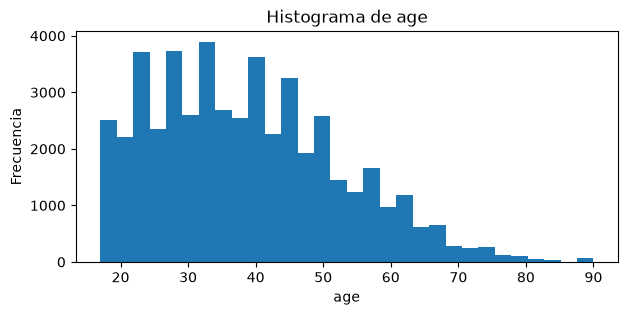

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\3451106128.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


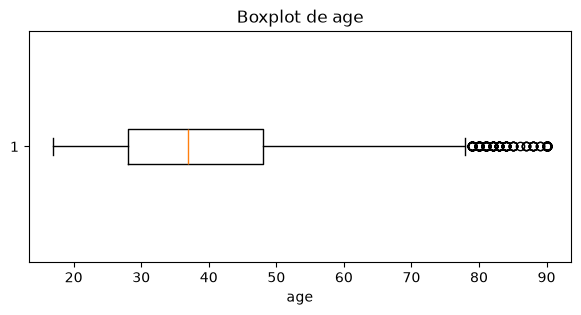

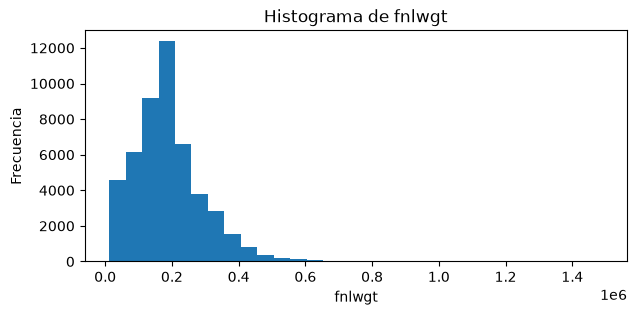

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\3451106128.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


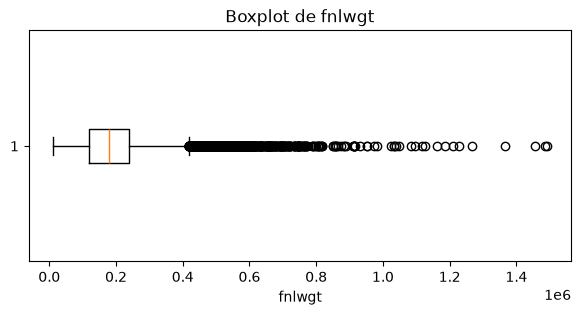

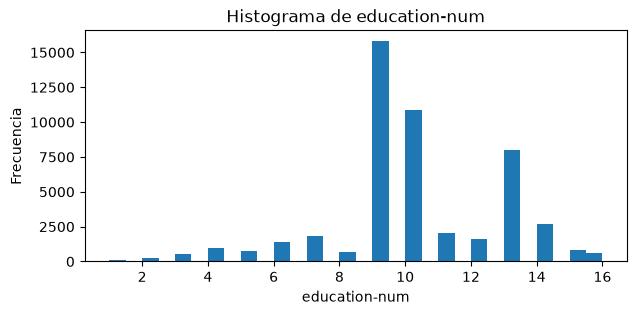

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\3451106128.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


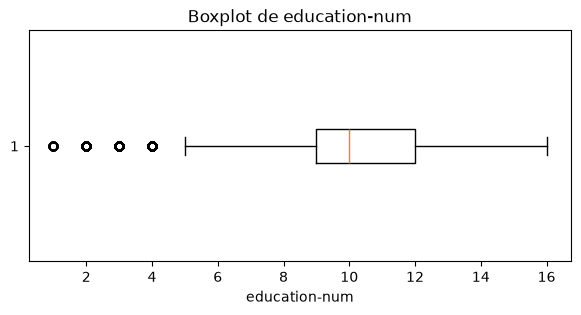

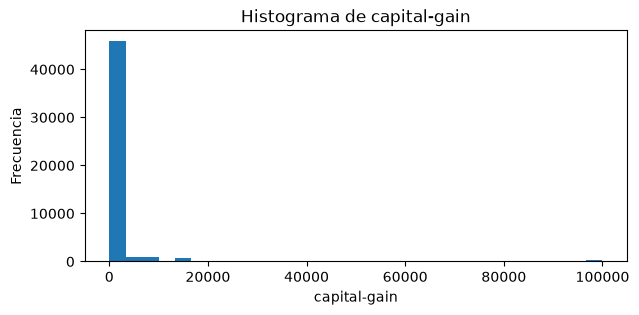

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\3451106128.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


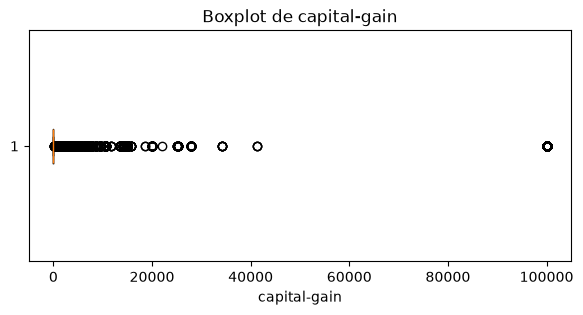

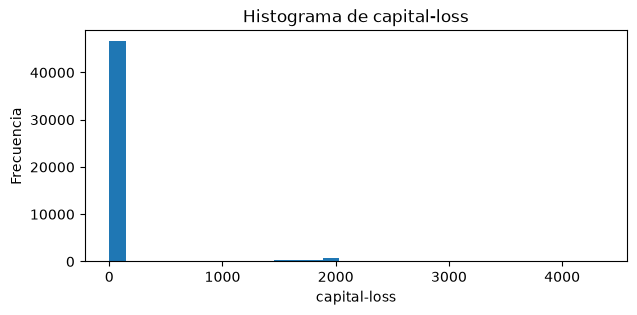

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\3451106128.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


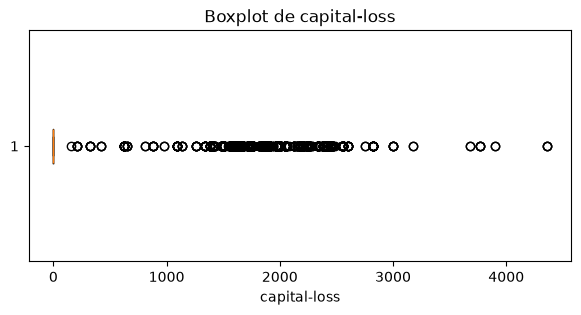

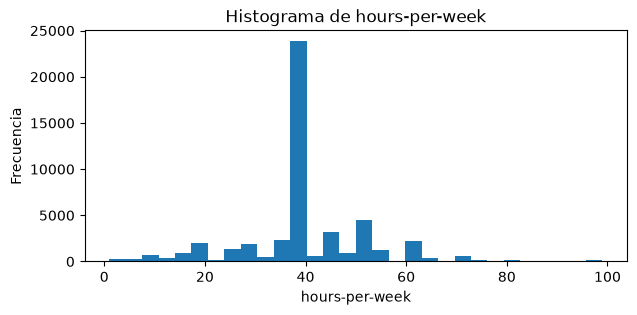

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\3451106128.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


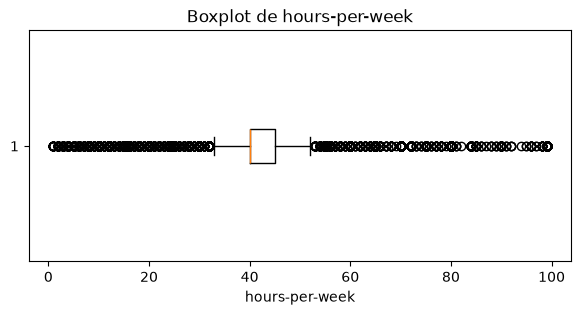

In [28]:
# Seguidamente, realizamos el histograma y el boxplot para cada una de las variables.
# Podemos observar que varias de ellas presentan distribuciones asimétricas, con una
# mayor concentración de observaciones en determinados rangos y colas hacia valores
# extremos.
# También podemos observar cómo capital-gain y capital-loss concentran una gran cantidad
# de sus valores en 0. Debemos recordar que estas variables corresponden a ganancias y
# pérdidas de capital, respectivamente. Por lo tanto, es razonable encontrar una alta
# concentración de valores en cero, ya que una gran parte de la población no reporta
# ganancias o pérdidas de capital.
# Ahora bien, al analizar los boxplots podemos observar que age presenta puntos fuera
# del bigote superior. Esto indica que las edades más elevadas son consideradas
# estadísticamente atípicas respecto a la distribución de la variable. Sin embargo,
# como verificamos anteriormente, estas edades son plausibles, por lo que no deben
# considerarse automáticamente como errores ni eliminarse.
# Seguidamente, observamos que los boxplots de capital-gain y capital-loss presentan
# una caja que visualmente parece una línea. Esto ocurre debido a que una gran cantidad
# de observaciones se concentra en 0, provocando que los cuartiles estén muy próximos
# o incluso coincidan. Como consecuencia, el IQR puede ser igual a 0 y los valores
# positivos aparecen visualmente como valores atípicos.

for col in numeric_cols:
    plt.figure(figsize=(7, 3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

In [29]:
#Definimos una funcion para realizar el método IQR para detectar posibles outliers.

def analizar_outliers_iqr(df, columna):

    # Primer cuartil
    Q1 = df[columna].quantile(0.25)

    # Tercer cuartil
    Q3 = df[columna].quantile(0.75)

    # Rango intercuartílico
    IQR = Q3 - Q1

    # Límites inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar valores fuera de los límites
    mascara_outliers = (
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    )

    # Número de outliers
    n_outliers = mascara_outliers.sum()

    # Porcentaje de outliers
    porcentaje_outliers = mascara_outliers.mean() * 100

    return {
        'variable': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': n_outliers,
        'porcentaje_outliers': porcentaje_outliers
    }

# Aplicamos IQR a todas las variables numéricas y observamos los resultados en la tabla.
# Vemos ciertas particularidades. Por ejemplo, el límite inferior de IQR para age es -2,
# mientras que el valor mínimo observado es 17, por lo que no existen outliers inferiores
# en esta variable. Lo mismo sucede para fnlwgt.
# Ahora bien, podemos ver que el IQR marca como outliers los valores de edad mayores a 78.
# Sin embargo, el valor máximo que encontramos en el dataset es de 90 años, lo cual es
# plausible, por lo que estos outliers no deben eliminarse.
# De la misma forma, se consideran outliers los valores de education-num que se encuentran
# fuera del intervalo entre 4.5 y 16.5. No obstante, ya verificamos que los valores máximos
# y mínimos observados en esta variable corresponden a niveles educativos válidos, por lo
# que no debemos eliminarlos.
# Para capital-gain, capital-loss y hours-per-week también es necesario analizar los valores
# atípicos antes de decidir si deben eliminarse.
# Más específicamente, la variable capital-gain presenta una fuerte concentración en cero,
# por lo que obtenemos un IQR de 0. Como consecuencia, el método IQR clasifica los valores
# positivos como atípicos. Este resultado no debe interpretarse como evidencia de errores,
# sino como una consecuencia de la distribución altamente asimétrica de la variable.
# Por tanto, IQR no se utilizará como criterio de eliminación para capital-gain.

resultados_iqr = []

for columna in numeric_cols:
    resultado = analizar_outliers_iqr(df, columna)
    resultados_iqr.append(resultado)

tabla_iqr = pd.DataFrame(resultados_iqr)

tabla_iqr



,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,porcentaje_outliers
0,age,28.0,48.0,20.0,-2.00,78.00,216,0.442242
1,fnlwgt,117550.5,237642.0,120091.5,-62586.75,417779.25,1453,2.974899
2,education-num,9.0,12.0,3.0,4.50,16.50,1794,3.673068
3,capital-gain,0.0,0.0,0.0,0.00,0.00,4035,8.261332
4,capital-loss,0.0,0.0,0.0,0.00,0.00,2282,4.672208
5,hours-per-week,40.0,45.0,5.0,32.50,52.50,13496,27.631956


In [30]:
# Una vez analizados los resultados obtenidos mediante el método IQR y consideradas
# las características propias de cada variable, se ha decidido mantener las
# observaciones identificadas como atípicas, ya que corresponden a valores válidos
# y pueden aportar información relevante para distinguir entre los individuos con
# ingresos superiores e inferiores a $50K.
# No obstante, se ha decidido aplicar una transformación logarítmica a las variables
# capital-gain y capital-loss. Aunque los valores atípicos presentes en estas variables
# son válidos y, por lo tanto, no se considera apropiado eliminarlos, ambas presentan
# una distribución fuertemente asimétrica y una alta concentración de observaciones
# en cero. La transformación logarítmica permitirá reducir la influencia relativa de
# los valores extremos y comprimir la escala de los valores positivos, conservando
# las observaciones originales.

#-------------------------------------------------------------
# Reconstruimos el DataFrame con los datos ya imputados
#-------------------------------------------------------------

# Unimos nuevamente entrenamiento y prueba
X_procesado = pd.concat([X_train, X_test])

# Unimos nuevamente la variable objetivo
y_procesado = pd.concat([y_train, y_test])

# Reconstruimos el DataFrame completo
df_procesado = X_procesado.copy()
df_procesado["income"] = y_procesado

# Transformación logarítmica
df_procesado['capital-gain-log'] = np.log1p(df_procesado['capital-gain'])
df_procesado['capital-loss-log'] = np.log1p(df_procesado['capital-loss'])

# Guardamos los datos procesados
df_procesado.to_csv("../data/datos_procesados.csv", index=False)

In [31]:
# ============================================================
# PARTE 4. Codificación de variables categóricas
# ============================================================


#Se aplicó Dummy Encoding con drop_first=True a todas las variables
# categóricas (excepto education, que fue eliminada, e income, que es la variable
# objetivo). Este método es el más apropiado para variables nominales porque no
# impone un orden artificial, permite que los modelos interpreten cada categoría
# de forma independiente, y al usar drop_first se evita la multicolinealidad.
# El dataset resultante pasó de 15 columnas originales a un conjunto expandido
# de variables binarias (0/1). Se decide eliminar education porque ya education_num
#tiene este feature codificado.



# 1. ¿Cuáles son las variables categóricas?

print(df_procesado.dtypes[df_procesado.dtypes == "object"])


# Imprimimos el contenido de las columnas para visualizarlo

print("=" * 60)
print("Primeras 10 líneas de las columnas categóricas")

display(
    df_procesado.select_dtypes(include="object").head(10)
)


# Copia del dataset para no modificar el original

df_encoded = df_procesado.copy()


# 2. Análisis de duplicado entre education y education-num

print("=" * 60)
print("Tabla de números relacionados a education")

display(
    df_procesado[["education", "education-num"]]
    .drop_duplicates()
    .sort_values("education-num")
)


# Eliminar columna education

df_encoded = df_encoded.drop(columns=["education"])


# 3. Obtener las variables categóricas restantes

categorical_columns = (
    df_encoded
    .select_dtypes(include="object")
    .columns
)


# Excluir la variable objetivo

categorical_columns = categorical_columns.drop(
    "income"
)


# 4. Aplicar Dummy Encoding

df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)


# 5. Ver el resultado

print("=" * 60)
print("Dataset codificado:")

display(df_encoded.head())


print("\nTipos de datos:")
print(df_encoded.dtypes)


print("\nDimensiones del dataset:")
print(df_encoded.shape)

Series([], dtype: object)
Primeras 10 líneas de las columnas categóricas


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\655226457.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_procesado.select_dtypes(include="object").head(10)


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
34495,Private,Bachelors,Never-married,Sales,Not-in-family,White,Female,United-States,<=50K
18591,Self-emp-inc,12th,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
12562,Private,HS-grad,Separated,Craft-repair,Not-in-family,White,Male,United-States,<=50K
552,Private,11th,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K
3479,State-gov,Masters,Never-married,Exec-managerial,Not-in-family,White,Female,United-States,<=50K
40259,Private,HS-grad,Married-civ-spouse,Other-service,Wife,White,Female,United-States,<=50K
23462,Private,Bachelors,Never-married,Exec-managerial,Not-in-family,White,Female,United-States,<=50K
30226,Private,Some-college,Never-married,Transport-moving,Not-in-family,White,Female,United-States,<=50K
44653,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,<=50K
18603,Self-emp-not-inc,Assoc-voc,Divorced,Other-service,Unmarried,White,Female,United-States,<=50K


Tabla de números relacionados a education


,education,education-num
36101,Preschool,1
31242,1st-4th,2
22373,5th-6th,3
20319,7th-8th,4
22994,9th,5
38604,10th,6
552,11th,7
18591,12th,8
12562,HS-grad,9
30226,Some-college,10


Dataset codificado:


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16116\655226457.py:58: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include="object")


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,capital-gain-log,capital-loss-log,workclass_Local-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
34495,37,193106,13,0,0,30,<=50K,0.0,0.000000,0,...,0,0,0,0,0,0,0,1,0,0
18591,56,216636,8,0,1651,40,<=50K,0.0,7.409742,0,...,0,0,0,0,0,0,0,1,0,0
12562,53,126977,9,0,0,35,<=50K,0.0,0.000000,0,...,0,0,0,0,0,0,0,1,0,0
552,72,205343,7,0,0,40,<=50K,0.0,0.000000,0,...,0,0,0,0,0,0,0,1,0,0
3479,46,106705,14,0,0,38,<=50K,0.0,0.000000,0,...,0,0,0,0,0,0,0,1,0,0



Tipos de datos:
age                               int64
fnlwgt                            int64
education-num                     int64
capital-gain                      int64
capital-loss                      int64
                                  ...  
native-country_Thailand           int64
native-country_Trinadad&Tobago    int64
native-country_United-States      int64
native-country_Vietnam            int64
native-country_Yugoslavia         int64
Length: 85, dtype: object

Dimensiones del dataset:
(48842, 85)


In [32]:
# ============================================================
# PARTE 5. Escalado
# ============================================================

# Se decidió aplicar un tratamiento diferenciado por tipo de variable, ya que no
# todas las distribuciones responden de la misma manera a un único método de escalado:
#
# 1. StandardScaler para "age" y "education-num":
#    Estas variables presentan distribuciones relativamente simétricas y no tienen
#    valores extremos que justifiquen un escalado robusto.
#
# 2. RobustScaler para "fnlwgt" y "hours-per-week":
#    Estas variables presentan valores extremos válidos que se desean conservar.
#    RobustScaler utiliza la mediana y el rango intercuartílico (IQR), por lo que
#    reduce la influencia de esos valores extremos.
#
# 3. "capital-gain" y "capital-loss" ya fueron transformadas previamente mediante
#    log1p en las columnas "capital-gain-log" y "capital-loss-log". únicamente se escalan
#    las columnas ya transformadas mediante StandardScaler.
#
# 4. Las variables dummy se mantienen sin escalar (remainder="passthrough"),
#    ya que son binarias (0/1).

import pandas as pd

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer


# ============================================================
# 1. SEPARAR PREDICTORES Y OBJETIVO
# ============================================================

# Se eliminan las variables originales capital-gain y capital-loss de X porque
# sus versiones logarítmicas ya fueron creadas anteriormente y serán las que se
# utilizarán en el conjunto procesado.
X = df_encoded.drop(
    columns=["income", "capital-gain", "capital-loss"]
)

y = df_encoded["income"]


# ============================================================
# 2. DEFINIR TRATAMIENTO POR VARIABLES
# ============================================================

# StandardScaler
standard_columns = [
    "age",
    "education-num",
    "capital-gain-log",
    "capital-loss-log"
]

# RobustScaler
robust_columns = [
    "fnlwgt",
    "hours-per-week"
]


# ============================================================
# 3. CREAR PREPROCESADOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "standard",
            StandardScaler(),
            standard_columns
        ),
        (
            "robust",
            RobustScaler(),
            robust_columns
        )
    ],

    # Mantener las variables dummy sin modificar
    remainder="passthrough",
    verbose_feature_names_out=False
)


# ============================================================
# 4. APLICAR EL ESCALADO
# ============================================================

X_scaled = preprocessor.fit_transform(X)


# ============================================================
# 5. CONVERTIR RESULTADO A DATAFRAME
# ============================================================

column_names = preprocessor.get_feature_names_out()

X_scaled = pd.DataFrame(
    X_scaled,
    columns=column_names,
    index=X.index
)


# ============================================================
# 6. VER RESULTADO
# ============================================================

print("=" * 60)
print("Dataset después del escalado:")
display(X_scaled.head())

print("=" * 60)
print("Dimensiones:")
print(X_scaled.shape)

print("=" * 60)
print("Tipos de datos:")
print(X_scaled.dtypes)


Dataset después del escalado:


,age,education-num,capital-gain-log,capital-loss-log,fnlwgt,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
34495,-0.119879,1.136512,-0.297918,-0.221264,0.124584,-2.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18591,1.265933,-0.808297,-0.297918,4.450068,0.320518,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12562,1.047121,-0.419335,-0.297918,-0.221264,-0.426071,-1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
552,2.432933,-1.197259,-0.297918,-0.221264,0.226481,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3479,0.536558,1.525474,-0.297918,-0.221264,-0.594876,-0.4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Dimensiones:
(48842, 82)
Tipos de datos:
age                               float64
education-num                     float64
capital-gain-log                  float64
capital-loss-log                  float64
fnlwgt                            float64
                                   ...   
native-country_Thailand           float64
native-country_Trinadad&Tobago    float64
native-country_United-States      float64
native-country_Vietnam            float64
native-country_Yugoslavia         float64
Length: 82, dtype: object


In [33]:
# ============================================================
# PARTE 5.5. EVALUACION DEL DESEQUILIBRIO DE CLASES
# ============================================================

# Primero, se corrigieron las etiquetas de la variable income. El dataset Adult
# de UCI contiene etiquetas duplicadas con y sin punto final ("<=50K" y "<=50K.",
# ">50K" y ">50K.") que corresponden a los subconjuntos de entrenamiento y prueba
# originales. Se eliminó el punto final para unificar las clases.
#
#
# CONCLUSIÓN: El dataset presenta un desequilibrio moderado (ratio ~3:1) que no
# justifica la aplicación de técnicas de remuestreo. Se conservan los pesos de
# clase calculados como herramienta disponible para la etapa de modelado, donde
# se evaluará si su uso mejora el rendimiento del clasificador.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight


# ============================================================
# 1. Corregir las clases de income
# ============================================================

# En Adult aparecen etiquetas como: <=50K y <=50K. >50K  y >50K.
# El punto final no representa una clase diferente, por lo que se elimina.

df_procesado["income"] = (
    df_procesado["income"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
)

# Convertimos la variable objetivo a valores numéricos donde 0 = <=50K y 1 = >50K

df_procesado["income"] = df_procesado["income"].map({
    "<=50K": 0,
    ">50K": 1
})



# ============================================================
# 2. CONTAR LAS CLASES
# ============================================================

class_counts = df_procesado["income"].value_counts()

class_percentages = (
    df_procesado["income"]
    .value_counts(normalize=True)
    .mul(100)
)


balance_table = pd.DataFrame({

    "Cantidad": class_counts,

    "Porcentaje": class_percentages

})


print("\n" + "=" * 60)
print("Distribucion de la variable income ")

display(balance_table)


# ============================================================
# 3. Calculo del ratio
# ============================================================

majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count


print("=" * 60)
print("RATIO DE DESEQUILIBRIO")

print(
    f"Clase mayoritaria: {class_counts.idxmax()} "
    f"({majority_count} casos)"
)

print(
    f"Clase minoritaria: {class_counts.idxmin()} "
    f"({minority_count} casos)"
)

print(
    f"Ratio mayoritaria/minoritaria: "
    f"{imbalance_ratio:.2f}:1"
)


# ============================================================
# 4. Interpretacion
# ============================================================

if imbalance_ratio >= 100:

    print(
        "Desequilibrio severo. "
        "Se requiere tratamiento."
    )

elif imbalance_ratio >= 10:

    print(
        "Existe un desequilibrio importante. "
        "Se recomienda considerar tratamiento."
    )

else:

    print(
        "El desequilibrio no supera el ratio 10:1. "
        "No se aplicara sobremuestreo ni submuestreo "
        "en esta etapa."
    )




Distribucion de la variable income 


,Cantidad,Porcentaje
income,,
0,37155,76.071823
1,11687,23.928177


RATIO DE DESEQUILIBRIO
Clase mayoritaria: 0 (37155 casos)
Clase minoritaria: 1 (11687 casos)
Ratio mayoritaria/minoritaria: 3.18:1
El desequilibrio no supera el ratio 10:1. No se aplicara sobremuestreo ni submuestreo en esta etapa.


CLASES DE LA VARIABLE OBJETIVO
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1))]

RESULTADOS ANOVA F-TEST
Variables numericas vs income


,Variable,F-score,p-value
2,education-num,6075.369398,0.000000e+00
3,capital-gain-log,4455.756647,0.000000e+00
0,age,2737.207112,0.000000e+00
5,hours-per-week,2670.362124,0.000000e+00
4,capital-loss-log,952.325022,4.091046e-207
1,fnlwgt,1.962526,1.612498e-01


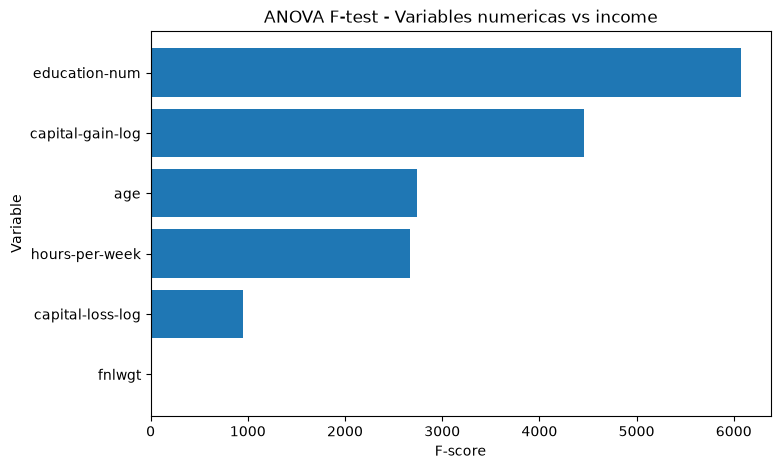


RESULTADOS CHI-CUADRADO
Variables categoricas vs income


,Variable,Chi2,p-value,Grados_libertad
3,relationship,10088.722490,0.000000e+00,5
1,marital-status,9816.015037,0.000000e+00,6
2,occupation,5822.033036,0.000000e+00,13
5,sex,2248.847679,0.000000e+00,1
0,workclass,1379.812775,9.004017e-294,7
4,race,487.026287,4.284378e-104,4
6,native-country,451.480381,4.302769e-71,40


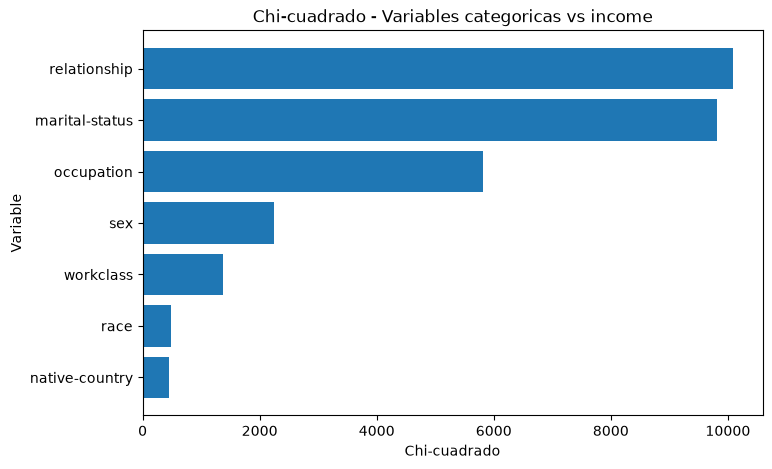


RESUMEN DE SELECCION DE ATRIBUTOS

1. VARIABLES NUMERICAS - ANOVA F-TEST


,Variable,F-score,p-value
2,education-num,6075.369398,0.000000e+00
3,capital-gain-log,4455.756647,0.000000e+00
0,age,2737.207112,0.000000e+00
5,hours-per-week,2670.362124,0.000000e+00
4,capital-loss-log,952.325022,4.091046e-207
1,fnlwgt,1.962526,1.612498e-01



2. VARIABLES CATEGORICAS - CHI-CUADRADO


,Variable,Chi2,p-value,Grados_libertad
3,relationship,10088.722490,0.000000e+00,5
1,marital-status,9816.015037,0.000000e+00,6
2,occupation,5822.033036,0.000000e+00,13
5,sex,2248.847679,0.000000e+00,1
0,workclass,1379.812775,9.004017e-294,7
4,race,487.026287,4.284378e-104,4
6,native-country,451.480381,4.302769e-71,40



Atributos predictores seleccionados:
['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain-log', 'capital-loss-log', 'hours-per-week', 'native-country']
CONCLUSION DEL ANALISIS DE DESEQUILIBRIO
El dataset presenta una diferencia entre las clases, pero el ratio no supera 10:1. Por lo tanto, no se aplicara sobremuestreo, submuestreo ni SMOTE en esta etapa.
Se conservaran los pesos de clase calculados para evaluar su posible uso durante el entrenamiento de algoritmos que admitan class_weight.


In [ ]:
# ============================================================
# PARTE 6. Seleccion de atributos
# ============================================================

# La selección de atributos busca identificar cuáles variables presentan evidencia
# de relación con la variable objetivo income y cuáles pueden considerarse poco
# relevantes o redundantes.
#
# En este análisis se utilizan únicamente dos métodos de filtro:
#
# 1. ANOVA F-test para predictores numéricos frente a un objetivo categórico.
# 2. Chi-cuadrado para predictores categóricos frente a un objetivo categórico.
#
# No se utiliza Información Mutua para tomar la decisión final de selección.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import f_classif
from scipy.stats import chi2_contingency


# ============================================================
# 1. PREPARAR VARIABLE OBJETIVO
# ============================================================

# La variable income ya se encuentra codificada:
y_selection = df_procesado["income"]

print("=" * 60)
print("CLASES DE LA VARIABLE OBJETIVO")

print(df_procesado["income"].unique())


# ============================================================
# 2. ANOVA F-TEST
# Predictor numerico vs objetivo categorico
# ============================================================

numeric_columns = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain-log",
    "capital-loss-log",
    "hours-per-week"
]

X_numeric = df_procesado[numeric_columns]

# Calcular F-score y p-value
f_scores, p_values = f_classif(
    X_numeric,
    y_selection
)

# Crear tabla de resultados
anova_resultado = pd.DataFrame({
    "Variable": numeric_columns,
    "F-score": f_scores,
    "p-value": p_values
})

# Ordenar de mayor a menor F-score
anova_resultado = anova_resultado.sort_values(
    "F-score",
    ascending=False
)

print("\n" + "=" * 60)
print("RESULTADOS ANOVA F-TEST")
print("Variables numericas vs income")
display(anova_resultado)

# Grafico ANOVA
plt.figure(figsize=(8,5))
plt.barh(
    anova_resultado["Variable"],
    anova_resultado["F-score"]
)
plt.xlabel("F-score")
plt.ylabel("Variable")
plt.title("ANOVA F-test - Variables numericas vs income")
plt.gca().invert_yaxis()
plt.show()


# ============================================================
# 3. CHI-CUADRADO
# Predictor categorico vs objetivo categorico
# ============================================================

# education no se incluye porque previamente se decidió eliminarla
# y conservar education-num.
categorical_columns = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

chi_resultados = []

for column in categorical_columns:

    # Crear tabla de contingencia
    contingency_table = pd.crosstab(
        df_procesado[column],
        df_procesado["income"]
    )

    # Aplicar prueba Chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_resultados.append({
        "Variable": column,
        "Chi2": chi2,
        "p-value": p_value,
        "Grados_libertad": dof
    })

# Crear DataFrame
chi_resultado = pd.DataFrame(chi_resultados)

# Ordenar por estadistico Chi2
chi_resultado = chi_resultado.sort_values(
    "Chi2",
    ascending=False
)

print("\n" + "=" * 60)
print("RESULTADOS CHI-CUADRADO")
print("Variables categoricas vs income")
display(chi_resultado)

# Grafico Chi-cuadrado
plt.figure(figsize=(8,5))
plt.barh(
    chi_resultado["Variable"],
    chi_resultado["Chi2"]
)
plt.xlabel("Chi-cuadrado")
plt.ylabel("Variable")
plt.title("Chi-cuadrado - Variables categoricas vs income")
plt.gca().invert_yaxis()
plt.show()


# ============================================================
# 4. RESUMEN DE RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESUMEN DE SELECCION DE ATRIBUTOS")

print("\n1. VARIABLES NUMERICAS - ANOVA F-TEST")
display(anova_resultado)

print("\n2. VARIABLES CATEGORICAS - CHI-CUADRADO")
display(chi_resultado)


# ============================================================
# 5. CONCLUSION DE LA SELECCION
# ============================================================

# ANOVA muestra evidencia estadísticamente significativa de relación con income
# para age, education-num, capital-gain, capital-loss y hours-per-week.
# fnlwgt presenta un p-value superior a 0.05, por lo que no se conserva como
# predictor en la selección final.
#
# Chi-cuadrado muestra asociación estadísticamente significativa con income para
# workclass, marital-status, occupation, relationship, race, sex y native-country,
# por lo que estas variables categóricas se conservan.
#
# education ya había sido eliminada previamente por redundancia con education-num.
# Por tanto, la selección final se basa únicamente en ANOVA F-test y Chi-cuadrado.

selected_features = [
    "age",
    "workclass",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain-log",
    "capital-loss-log",
    "hours-per-week",
    "native-country"
]

print("\nAtributos predictores seleccionados:")
print(selected_features)


print("=" * 60)
print("CONCLUSION DEL ANALISIS DE DESEQUILIBRIO")

print(
    "El dataset presenta una diferencia entre las clases, "
    "pero el ratio no supera 10:1. "
    "Por lo tanto, no se aplicara sobremuestreo, "
    "submuestreo ni SMOTE en esta etapa."
)

print(
    "Se conservaran los pesos de clase calculados "
    "para evaluar su posible uso durante el entrenamiento "
    "de algoritmos que admitan class_weight."
)

In [ ]:
# ============================================================
# PARTE 7. Guardar dataset final
# ============================================================

# Seleccionamos únicamente las variables que se conservarán
# para la etapa de modelado, junto con la variable objetivo.

df_final = X_scaled.copy()

# -----------------------------------------------------------
# 1. Eliminamos las variables que no fueron seleccionadas
# -----------------------------------------------------------

# fnlwgt fue descartada durante la selección de atributos
if "fnlwgt" in df_final.columns: df_final = df_final.drop(columns=["fnlwgt"])


# -----------------------------------------------------------
# 2. Agregamos la variable objetivo
# -----------------------------------------------------------

df_final["income"] = df_procesado["income"].values

# -----------------------------------------------------------
# 1. Verificamos el dataset
# -----------------------------------------------------------

print("=" * 60)
print("DATASET FINAL PARA MODELADO")

display(df_final.head())

print("\nDimensiones:")
print(df_final.shape)

print("\nColumnas:")
print(df_final.columns.tolist())

print("\nValores faltantes:")
print(df_final.isnull().sum())

print("\nTipos de datos:")
print(df_final.dtypes)


# -----------------------------------------------------------
# 2. Guardamos el dataset
# -----------------------------------------------------------

df_final.to_csv("../data/datos_finales.csv", index=False)

print("\n" + "=" * 60)
print("Dataset final guardado correctamente")
print("../data/datos_finales.csv")
print("=" * 60)

DATASET FINAL PARA MODELADO


,age,education-num,capital-gain-log,capital-loss-log,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
34495,-0.119879,1.136512,-0.297918,-0.221264,-2.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,<=50K
18591,1.265933,-0.808297,-0.297918,4.450068,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,<=50K
12562,1.047121,-0.419335,-0.297918,-0.221264,-1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,<=50K
552,2.432933,-1.197259,-0.297918,-0.221264,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,<=50K
3479,0.536558,1.525474,-0.297918,-0.221264,-0.4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,<=50K



Dimensiones:
(48842, 82)

Columnas:
['age', 'education-num', 'capital-gain-log', 'capital-loss-log', 'hours-per-week', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 